# 01 — Sets and Maps

This notebook begins the mathematical foundations needed for Geometric Deep Learning.

The main reference is **§1.1, “Sets, Maps, and Functions,”** of Haitz Sáez de Ocáriz Borde and Michael Bronstein, *Mathematical Foundations of Geometric Deep Learning*, arXiv:2508.02723.

The purpose is not to reproduce the text, but to turn its basic objects into a small computational laboratory.

The guiding workflow is

$$
\text{mathematical definition}
\;\longrightarrow\;
\text{example/non-example}
\;\longrightarrow\;
\text{Python representation}
\;\longrightarrow\;
\text{experiment}.
$$

We will study sets, set operations, Cartesian products, maps and functions, injective/surjective/bijective maps, composition, and hypothesis classes.

## 1. Sets

A **set** is a collection of distinct objects. The objects may be numbers, symbols, functions, sets, or other mathematical objects.

If $x$ is an element of $A$, we write

$$
x\in A.
$$

For example,

$$
A=\{1,2,3\},\qquad 2\in A,\qquad 5\notin A.
$$

### Example

$$
\{1,2,3\}=\{3,1,2\}.
$$

Order does not matter.

In [1]:
# A Python set is written using curly braces.
A = {1, 2, 3}

print(A)

# Membership is tested with `in`.
print(2 in A)
print(5 in A)

# Reordering the elements does not change the set.
B = {3, 1, 2}
print(A == B)

# Duplicate entries are collapsed automatically.
C = {1, 1, 2, 2, 3}
print(C)
print(len(C))


{1, 2, 3}
True
False
True
{1, 2, 3}
3


### Exercise 1

Construct a Python set representing

$$
A=\{2,4,6,8,10\}.
$$

Check whether $6\in A$ and $7\in A$.

**Further question:** Can you think of another mathematical object that is not naturally represented by a Python `set`.

## 2. Set-builder notation

A set can be specified by a property its elements satisfy. For example,

$$
E=\{x\in\mathbb N\mid x\text{ is even}\}.
$$

Python **set comprehensions** provide a close computational analogue.

As in the article, the ambient set matters. For example,

$$
\{x\in\mathbb Z\mid x^2=2\}=\emptyset,
$$

because $\sqrt2$ and $-\sqrt2$ are not integers.

In [3]:
# Set comprehension: collect even integers from 1 through 20.
E = {x for x in range(1, 21) if x % 2 == 0}

print(E)

# The equation x^2 = 2 has no integer solutions.
integer_solutions = {x for x in range(-10, 11) if x**2 == 2}
print(integer_solutions)


{2, 4, 6, 8, 10, 12, 14, 16, 18, 20}
set()


## 3. Subsets and set operations

A set $A$ is a subset of $B$ if every element of $A$ is also an element of $B$:

$$
A\subseteq B
\quad\Longleftrightarrow\quad
\forall x\,(x\in A\Rightarrow x\in B).
$$

For sets $A$ and $B$,

$$
A\cup B=\{x\mid x\in A\text{ or }x\in B\},
$$

$$
A\cap B=\{x\mid x\in A\text{ and }x\in B\},
$$

$$
A\setminus B=\{x\in A\mid x\notin B\}.
$$

### Example

For

$$
A=\{1,2,3\},\qquad B=\{2,3,4\},
$$

we have

$$
A\cup B=\{1,2,3,4\},\quad
A\cap B=\{2,3\},\quad
A\setminus B=\{1\}.
$$

### Non-example

If $A=\{1,2,3\}$ and $B=\{1,5\}$, then $B\subseteq A$ is false.

In [4]:
A = {1, 2, 3}
B = {2, 3, 4}

# Python set operators mirror the standard mathematical operations.
print("A union B        =", A | B)
print("A intersection B =", A & B)
print("A difference B    =", A - B)

# Subset and proper-subset tests.
print("A subset of B?   =", A <= B)
print("A proper subset? =", A < B)


A union B        = {1, 2, 3, 4}
A intersection B = {2, 3}
A difference B    = {1}
A subset of B?   = False
A proper subset? = False


## 4. Complements and the power set

A complement requires an ambient universal set $U$. For $A\subseteq U$,

$$
A^c=U\setminus A.
$$

The **power set** of $A$ is

$$
\mathcal P(A)=\{B\mid B\subseteq A\}.
$$

If $A$ is finite with $|A|=n$, then

$$
|\mathcal P(A)|=2^n.
$$

For

$$
A=\{1,2\},
$$

we have

$$
\mathcal P(A)=\{\emptyset,\{1\},\{2\},\{1,2\}\}.
$$

We have to use Python's `frozenset` if we want to creat a class: a set of sets. This is because a mutable `set` cannot itself be an element of another set.

In [6]:
from itertools import combinations

def power_set(A):
    # Convert to a list so we can generate subsets by size.
    A = list(A)

    # Each subset is obtained by choosing k elements.
    return {
        frozenset(subset)
        for k in range(len(A) + 1)
        for subset in combinations(A, k)
    }

A = {1, 2, 3}
P_A = power_set(A)

print("A =", A)
print("Power set =", P_A)
print("Number of subsets =", len(P_A))
print("Expected number =", 2 ** len(A))


A = {1, 2, 3}
Power set = {frozenset({2}), frozenset({2, 3}), frozenset({1, 2}), frozenset({1, 2, 3}), frozenset({3}), frozenset({1}), frozenset(), frozenset({1, 3})}
Number of subsets = 8
Expected number = 8


## 5. Cardinality and infinite sets

For a finite set $A$, its cardinality $|A|$ is its number of elements.

For infinite sets, cardinality is defined through bijections. Consider

$$
\mathbb N=\{1,2,3,\ldots\}
$$

and

$$
E=\{2,4,6,\ldots\}.
$$

Although $E\subsetneq\mathbb N$, the map

$$
f:\mathbb N\to E,\qquad f(n)=2n
$$

is a bijection. Thus the two sets have the same cardinality.

This is one of the first places where finite-set intuition differs sharply from infinite-set intuition.

In [7]:
# A finite computational approximation to the map n -> 2n.
N = set(range(1, 11))

def double(n):
    # Map n to 2n.
    return 2 * n

E = {double(n) for n in N}

print("N =", N)
print("E =", E)


N = {1, 2, 3, 4, 5, 6, 7, 8, 9, 10}
E = {2, 4, 6, 8, 10, 12, 14, 16, 18, 20}


**Remark:** If you are further interested, take a look at Hausdorff's Set Theory. Also, look at `Pigeon Hole Principle` and Hilbert Hotel example.

## 6. Cartesian products

Given sets $A$ and $B$, their Cartesian product is

$$
A\times B
=
\{(a,b)\mid a\in A,\ b\in B\}.
$$

Its elements are ordered pairs.

If $A$ and $B$ are finite,

$$
|A\times B|=|A||B|.
$$

### Example

$$
\{1,2\}\times\{x,y\}
=
\{(1,x),(1,y),(2,x),(2,y)\}.
$$

In [8]:
A = {1, 2}
B = {"x", "y"}

# A Cartesian product can be generated with a nested comprehension.
A_times_B = {(a, b) for a in A for b in B}

print(A_times_B)
print("Cardinality =", len(A_times_B))


{(2, 'x'), (2, 'y'), (1, 'x'), (1, 'y')}
Cardinality = 4


## 7. Maps and functions

A map from $A$ to $B$ is written

$$
F:A\to B.
$$

Here $A$ is the **domain** and $B$ is the **codomain**. For each $a\in A$, the value $F(a)\in B$ is its image.

A function assigns **exactly one** output to every element of its domain.

### Example

$$
F:\mathbb N\to\mathbb Z,
\qquad F(n)=n^2.
$$

### Non-example

The rule

$$
g:\mathbb R\to\mathbb R,
\qquad g(x)=\frac1x
$$

does not define a function on all of $\mathbb R$, because $g(0)$ is undefined. It does define a function

$$
g:\mathbb R\setminus\{0\}\to\mathbb R.
$$

Python functions are computational rules, but a Python callable does not automatically record its mathematical domain and codomain.

In [9]:
# A Python function is a computational rule.
def square(x):
    # Return the square of the input.
    return x ** 2

print(square(3))
print(square(-2))


9
4


### Domain, codomain, and image

The image of $f:A\to B$ is

$$
f(A)=\{f(a)\mid a\in A\}.
$$

It always satisfies

$$
f(A)\subseteq B.
$$

For computational experiments with finite sets, we can explicitly store the domain and codomain.

In [10]:
# Explicitly choose a finite domain and codomain.
domain = {1, 2, 3, 4}
codomain = {1, 4, 9, 16, 25}

def square_on_domain(x):
    # This rule is intended to be evaluated only on `domain`.
    return x ** 2

image = {square_on_domain(x) for x in domain}

print("Domain   =", domain)
print("Codomain =", codomain)
print("Image    =", image)
print("Image is a subset of codomain?", image <= codomain)


Domain   = {1, 2, 3, 4}
Codomain = {16, 1, 4, 9, 25}
Image    = {16, 1, 4, 9}
Image is a subset of codomain? True


## 8. Injective, surjective, and bijective maps

Let

$$
f:A\to B.
$$

The map is **injective** if

$$
f(a_1)=f(a_2)\Rightarrow a_1=a_2.
$$

It is **surjective** if

$$
\forall b\in B,\ \exists a\in A\text{ such that }f(a)=b,
$$

equivalently,

$$
f(A)=B.
$$

It is **bijective** if it is both injective and surjective.

A bijection gives a one-to-one correspondence between two sets.

In [11]:
def is_injective(function, domain):
    # For a finite domain, injectivity means all outputs are distinct.
    outputs = [function(x) for x in domain]
    return len(outputs) == len(set(outputs))


def is_surjective(function, domain, codomain):
    # Surjectivity means that the image equals the codomain.
    image = {function(x) for x in domain}
    return image == codomain


def is_bijective(function, domain, codomain):
    # A bijection is both injective and surjective.
    return (
        is_injective(function, domain)
        and is_surjective(function, domain, codomain)
    )


# Example: a bijection between two finite sets.
A = {1, 2, 3}
B = {2, 4, 6}

def double(x):
    # Map x to 2x.
    return 2 * x

print("Injective:", is_injective(double, A))
print("Surjective:", is_surjective(double, A, B))
print("Bijective:", is_bijective(double, A, B))


Injective: True
Surjective: True
Bijective: True


### Example and non-example

Consider

$$
f:\{1,2,3\}\to\{a,b,c,d\}.
$$

If

$$
f(1)=a,\quad f(2)=b,\quad f(3)=c,
$$

then $f$ is injective but not surjective: $d$ is not hit.

For finite sets of the same cardinality, injectivity and surjectivity are equivalent.

## 9. Composition

Suppose

$$
f:X\to Y
$$

and

$$
g:Y\to Z.
$$

Their composition is

$$
g\circ f:X\to Z,
$$

defined by

$$
(g\circ f)(x)=g(f(x)).
$$

In general,

$$
g\circ f\neq f\circ g.
$$

For

$$
f(x)=x^2,\qquad g(x)=\sin(x),
$$

we obtain

$$
(g\circ f)(x)=\sin(x^2),
$$

whereas

$$
(f\circ g)(x)=\sin^2(x).
$$

In [12]:
import math

def f(x):
    # Square the input.
    return x ** 2

def g(x):
    # Apply the sine function.
    return math.sin(x)

def g_after_f(x):
    # Compute (g o f)(x) = g(f(x)).
    return g(f(x))

def f_after_g(x):
    # Compute (f o g)(x) = f(g(x)).
    return f(g(x))

x = 1.0

print("(g o f)(x) =", g_after_f(x))
print("(f o g)(x) =", f_after_g(x))


(g o f)(x) = 0.8414709848078965
(f o g)(x) = 0.7080734182735712


## 10. Connection with Deep Learning

The elementary objects introduced above—sets, maps, functions, and composition—are not merely
formal preliminaries. They appear directly in the mathematical description of modern machine
learning models.

This section collects several of the explicit connections made in §1.1 of Borde–Bronstein.
The goal is to keep the mathematical definitions separate from their machine-learning
interpretations, while making the bridge between them visible.

We will look at:

1. sets and graphs, with a brief connection to Graph Neural Networks;
2. function composition and deep learning;
3. hypothesis classes;
4. neural-network architectures as parameterized compositions of functions.

### 10.1 Sets in Geometric Deep Learning: graphs and GNNs

A graph is built from sets. A simple graph can be written as

$$
G=(V,E),
$$

where $V$ is a set of vertices and

$$
E\subseteq V\times V
$$

is a set of edges (for an undirected graph, the edge relation has the appropriate symmetry).

For example,

$$
V=\{1,2,3,4\},
$$

and

$$
E=\{(1,2),(2,3),(3,4),(4,1)\}
$$

describes a cycle graph when the pairs are interpreted as undirected edges.

Thus a graph is already an example of a mathematical object constructed from sets and
Cartesian products.

This matters in **Geometric Deep Learning** because graphs are one of the central non-Euclidean
domains on which neural networks operate. A **Graph Neural Network (GNN)** associates data
such as feature vectors to the vertices (and sometimes edges) and updates these features using
the graph's connectivity structure.

For a vertex $v$, a typical message-passing layer has the schematic form

$$
h_v' =
\Phi\left(
h_v,
\operatorname{AGG}\left(
\{\Psi(h_v,h_u):u\in N(v)\}
\right)
\right),
$$

where $N(v)$ is the neighborhood of $v$, `AGG` is an aggregation operation, and
$\Phi,\Psi$ are learnable functions.

The set-theoretic viewpoint is useful here: the graph supplies the sets and relations that
specify **which objects interact with which**. In GNNs, neighborhood aggregation is also
naturally permutation-invariant; the ordering in which neighbors are presented should not
change the result.

The article also points out that **multisets** arise naturally in GNNs. Unlike an ordinary
set, a multiset permits repeated elements. This is useful when the neighborhood is represented
through a collection of messages or feature values, where the same value can occur more than
once.

So even the elementary distinction between sets and multisets has a concrete role in GDL.

In [13]:
# A small graph represented directly by two sets.
# V is the set of vertices.
V = {1, 2, 3, 4}

# E is a set of ordered pairs representing the edges of a cycle.
E = {(1, 2), (2, 3), (3, 4), (4, 1)}

print("Vertices:", V)
print("Edges:", E)

# The neighborhood of a vertex can be extracted from the edge set.
def neighbors(v, edges):
    # Collect vertices u for which (v, u) is an edge.
    return {u for (a, u) in edges if a == v}

print("Neighbors of 2:", neighbors(2, E))


Vertices: {1, 2, 3, 4}
Edges: {(2, 3), (1, 2), (4, 1), (3, 4)}
Neighbors of 2: {3}


### 10.2 Function composition and Deep Learning

The composition

$$
g\circ f
$$

is defined by

$$
(g\circ f)(x)=g(f(x)).
$$

This elementary operation is one of the basic mathematical ideas behind a deep neural
network. A network with several layers applies one transformation after another:

$$
f
=
f_L\circ f_{L-1}\circ\cdots\circ f_2\circ f_1.
$$

The output of one layer becomes the input of the next.

The article illustrates this using classical convolutional neural networks: feature maps
produced by one layer are passed to the next layer, where they are transformed into new
feature maps. The successive transformations therefore form a composition of functions.

The important point is that **depth corresponds mathematically to repeated function
composition**. The individual functions may be affine maps, nonlinear activations,
convolutions, attention operations, or geometric/equivariant transformations.

In [14]:
# A simple three-stage composition, analogous to a tiny neural network.
def affine(x):
    # First transformation.
    return 2 * x + 1

def relu(x):
    # A simple nonlinear activation.
    return max(0, x)

def output(x):
    # Final transformation.
    return 3 * x

def network(x):
    # Compose the three functions in sequence:
    # output(relu(affine(x))).
    return output(relu(affine(x)))

for x in [-2, 0, 1, 3]:
    print(f"x = {x:>2}, network(x) = {network(x)}")


x = -2, network(x) = 0
x =  0, network(x) = 3
x =  1, network(x) = 9
x =  3, network(x) = 21


### 10.3 Hypothesis classes

A **hypothesis class** is a collection of candidate functions.

For example, the affine functions from $\mathbb R^d$ to $\mathbb R$ form

$$
\mathcal F_{\mathrm{aff}}
=
\left\{
f_{w,b}:\mathbb R^d\to\mathbb R
\mid
f_{w,b}(x)=w^\top x+b
\right\}.
$$

In Deep Learning, an architecture defines a much richer hypothesis class. For an MLP, we
can write schematically

$$
\mathcal F_{\mathrm{NN}}
=
\left\{
f_\theta:\mathcal X\to\mathcal Y
\mid
\theta\in\Theta
\right\}.
$$

The parameter $\theta$ collects the weights and biases of the network. Training changes
$\theta$, and hence selects one particular function from the hypothesis class.

Thus there are two levels to keep distinct:

- the **architecture** determines the family of functions that can be represented;
- **learning** selects parameters within that family.

In [15]:
import numpy as np

def affine_function(w, b):
    # Return the affine function x -> w^T x + b.
    def f(x):
        # Convert x to a NumPy array for the dot product.
        x = np.asarray(x)
        return np.dot(w, x) + b

    return f


# One particular member of the affine hypothesis class.
w = np.array([2.0, -1.0])
b = 0.5

f = affine_function(w, b)
x = np.array([3.0, 4.0])

print(f(x))


2.5


#### Experiment: a family of functions

For the one-dimensional affine model

$$
f_{a,b}(x)=ax+b,
$$

each pair $(a,b)\in\mathbb R^2$ determines one function.

We can therefore view

$$
\mathcal F_{\mathrm{aff}}
=
\{f_{a,b}\mid(a,b)\in\mathbb R^2\}
$$

as a family of functions parameterized by $\mathbb R^2$.

This is a simple instance of the broader idea that a model architecture defines a structured
family of functions.

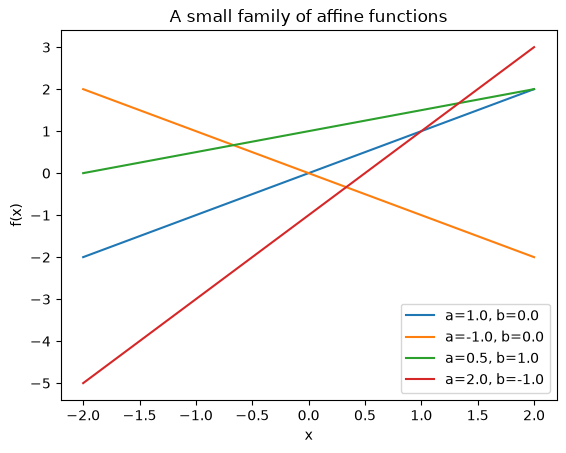

In [16]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 200)

# Each pair (a, b) gives one function f(x) = ax + b.
parameters = [
    (1.0, 0.0),
    (-1.0, 0.0),
    (0.5, 1.0),
    (2.0, -1.0),
]

for a, b in parameters:
    # Plot one member of the hypothesis class.
    y = a * x + b
    plt.plot(x, y, label=f"a={a}, b={b}")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("A small family of affine functions")
plt.legend()
plt.show()


### 10.4 Neural networks as compositions of parameterized functions

The MLP example in the article makes the previous two ideas meet.

A multilayer perceptron can be written schematically as

$$
f_\theta
=
\sigma_L\circ A_L\circ
\sigma_{L-1}\circ A_{L-1}\circ
\cdots\circ
\sigma_1\circ A_1,
$$

where each $A_i$ is an affine map and each $\sigma_i$ is a nonlinear activation.

The parameters are collected into

$$
\theta=
\{W^{(1)},b^{(1)},\ldots,W^{(L)},b^{(L)}\}.
$$

Thus the hypothesis class of the architecture consists of functions obtained by composing
maps of these forms while allowing the parameters to vary.

This gives a useful conceptual chain:

$$
\boxed{
\text{sets}
\rightarrow
\text{maps}
\rightarrow
\text{composition}
\rightarrow
\text{hypothesis classes}
\rightarrow
\text{deep neural networks}.
}
$$

For Geometric Deep Learning, the same chain will later be enriched by additional structure:
groups and symmetries, vector spaces, manifolds, graphs, and other geometric domains.

**Remark:** Check Hilbert 13th problem and `Kolmogorove-Arnold Representation Theorem`. Later, we will learn about the `Universal Approximation Theorem`.

### A useful perspective for GDL

At this stage, the important point is not yet to study a particular GNN or equivariant
architecture. Rather, we should recognize the mathematical language in which those models
will be expressed.

A GDL model can involve:

- a **set** of objects such as vertices;
- a **Cartesian product** describing pairs or tuples of objects;
- a **map** describing a transformation of data;
- a **composition** of many maps;
- a **hypothesis class** determined by an architecture;
- additional structure on the underlying sets, such as a graph, group action, metric,
  topology, or manifold structure.

The later chapters of the GDL foundations build precisely these additional structures.

## 11. Summary

| Mathematical object | Notation | Python analogue |
|---|---|---|
| Set | $A$ | `set` |
| Membership | $x\in A$ | `x in A` |
| Subset | $A\subseteq B$ | `A <= B` |
| Union | $A\cup B$ | `A \| B` |
| Intersection | $A\cap B$ | `A & B` |
| Difference | $A\setminus B$ | `A - B` |
| Cartesian product | $A\times B$ | set comprehension |
| Power set | $\mathcal P(A)$ | custom function |
| Function | $f:A\to B$ | Python `def` / callable |
| Image | $f(A)$ | `{f(x) for x in A}` |
| Composition | $g\circ f$ | nested function calls |
| Hypothesis class | $\mathcal F$ | collection/family of functions |

Python objects are **representations** of mathematical objects, not the mathematical objects themselves. In particular, the mathematical notion of a function includes its domain and codomain; a Python callable does not automatically encode those pieces of structure.

That distinction will become increasingly important for structured spaces, symmetries, graphs, manifolds, and equivariant maps.

## Exercises

### Exercise 2 — Sets

Let

$$
A=\{1,2,3,4\},
\qquad
B=\{3,4,5,6\}.
$$

Compute, both mathematically and in Python,

$$
A\cup B,\qquad
A\cap B,\qquad
A\setminus B,\qquad
B\setminus A.
$$

### Exercise 3 — Power sets

Verify experimentally that

$$
|\mathcal P(A)|=2^{|A|}
$$

for several finite sets.

### Exercise 4 — Maps

Construct finite sets $A$ and $B$ and define:

1. an injective but non-surjective map;
2. a surjective but non-injective map;
3. a bijective map.

Verify each property computationally.

### Exercise 5 — Composition

Find two functions $f$ and $g$ for which

$$
g\circ f\neq f\circ g.
$$

Then give an example for which the two compositions agree.

### Exercise 6 — Your own examples and non-examples

For each of the following, give one additional example and one non-example:

- a set;
- a subset;
- an injective map;
- a surjective map;
- a bijective map;
- a function.

For at least one example, explain where the Python representation agrees with the mathematical structure and where it does not.

### Additional Exercises:
- Learn About Zeno's Paradox and Euclid's fifth axiom (don't confuse with fifth postulate).
- Learn about Cantor's and Russel Paradox. Note that the power set is always bigger than the set.
- Can a set of all sets exist?

## References

1. **Haitz Sáez de Ocáriz Borde and Michael Bronstein**, *Mathematical Foundations of Geometric Deep Learning*, arXiv:2508.02723 (2025), especially §1.1, “Sets, Maps, and Functions.”  
   https://arxiv.org/abs/2508.02723

2. **Felix Hausdorff**, *Set Theory*, translated from the third German edition of *Mengenlehre*, Chelsea Publishing Company / AMS Chelsea Publishing. The work develops foundational set-theoretic notions including sets, systems of sets, cardinal and ordinal numbers, and mappings.

3. **Michael M. Bronstein, Joan Bruna, Taco Cohen, and Petar Veličković**, *Geometric Deep Learning: Grids, Groups, Graphs, Geodesics, and Gauges*, arXiv:2104.13478 (2021).  
   https://arxiv.org/abs/2104.13478

The discussion of graphs, GNNs, function composition, and neural-network hypothesis classes in Section 10 follows the connections made in §1.1 of the Borde–Bronstein notes. The Hausdorff reference is included as a classical source for the underlying set-theoretic language; the Borde–Bronstein notes provide the direct GDL mathematical context.